In [6]:
from torch_snippets import *
import selectivesearch
import numpy as np

def extract_candidates(img):
    img_lbl, regions = selectivesearch.selective_search(img, scale=200, min_size=100)
    img_area = np.prod(img.shape[:2])
    candidates = []
    for r in regions:
        if r['rect'] in candidates: 
            continue
        if r['size'] < (0.05 * img_area): 
            continue
        if r['size'] > (1 * img_area): 
            continue
            
        x, y, w, h = r['rect']
        candidates.append(list(r['rect']))
        
    return candidates

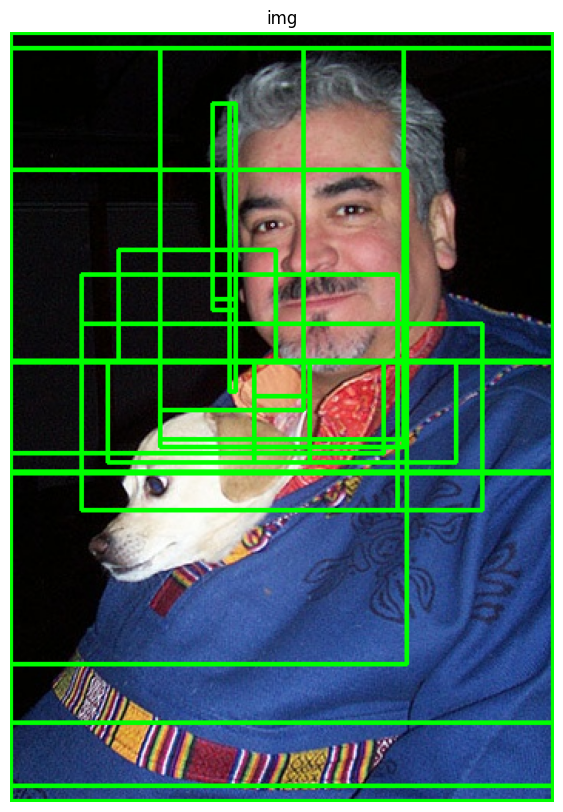

In [7]:
img = read('/kaggle/computer-vision-self-learning/assets/000001.jpg', 1)
candidates = extract_candidates(img)
show(img, bbs=candidates)

In [8]:
def get_iou(boxA, boxB, epsilon=1e-5):
    """
    Tính chỉ số IoU giữa hai hộp bao boxA và boxB.
    Tọa độ đầu vào định dạng: [xmin, ymin, xmax, ymax]
    epsilon: một hằng số rất nhỏ để tránh lỗi chia cho 0 nếu diện tích hợp bằng 0.
    """
    x1 = max(boxA[0], boxB[0])  # Cạnh trái nhất của vùng giao
    y1 = max(boxA[1], boxB[1])  # Cạnh trên nhất của vùng giao
    x2 = min(boxA[2], boxB[2])  # Cạnh phải nhất của vùng giao
    y2 = min(boxA[3], boxB[3])  # Cạnh dưới nhất của vùng giao
    
    width = (x2 - x1)
    height = (y2 - y1)
    
    if (width < 0) or (height < 0):
        return 0.0
        
    area_overlap = width * height
    
    area_a = (boxA[2] - boxA[0]) * (boxA[3] - boxA[1])
    area_b = (boxB[2] - boxB[0]) * (boxB[3] - boxB[1])
    
    area_combined = area_a + area_b - area_overlap
    
    iou = area_overlap / (area_combined + epsilon)
    return iou

In [9]:
box_ground_truth = [100, 100, 300, 300]
box_prediction = [150, 150, 350, 350]

print("Chỉ số IoU thu được:", get_iou(box_ground_truth, box_prediction))

Chỉ số IoU thu được: 0.391304347758034


In [10]:
import torch
import torchvision.ops as ops

boxes = torch.tensor([
    [100, 100, 210, 210], 
    [105, 102, 212, 213], 
    [102, 300, 210, 400]  
], dtype=torch.float)

scores = torch.tensor([0.92, 0.88, 0.75], dtype=torch.float)

iou_threshold = 0.5

keep_indices = ops.nms(boxes, scores, iou_threshold)

print("Các chỉ số hộp bao được GIỮ LẠI:", keep_indices.tolist())
print("Tọa độ các hộp bao tối ưu sau khi lọc:\n", boxes[keep_indices].tolist())

Các chỉ số hộp bao được GIỮ LẠI: [0, 2]
Tọa độ các hộp bao tối ưu sau khi lọc:
 [[100.0, 100.0, 210.0, 210.0], [102.0, 300.0, 210.0, 400.0]]
